# Modulo 2 · Tema 2 — Imputacion Avanzada de Valores Faltantes
## Diplomado: Machine Learning en Seguros · FC UNAM · 2026

---

> **Objetivo:** aprender a diagnosticar por que faltan los datos
> y elegir la estrategia de imputacion correcta.
> Una mala imputacion sesga el modelo — una buena lo mejora.

---

**Soluciones de los ejercicios:** `python soluciones_m2t2.py`

---
## Setup


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import time, os
import warnings
warnings.filterwarnings('ignore')

# sklearn — imputacion
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

mpl.rcParams['figure.dpi']        = 110
mpl.rcParams['axes.spines.top']   = False
mpl.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

# Cargar la tabla maestra de S9 — tiene todas las columnas incluyendo
# n_siniestros y monto_pagado que vienen del merge con siniestros
rutas = [
    '../../Modulo1/sesion8/datos/cartera_q1_2026_final.parquet',
    '../../Modulo1/sesion9/datos/cartera_q1_2026_final.parquet',
    '../../Modulo1/sesion10/datos/cartera_q1_2026_final.parquet'
]
ruta = next((r for r in rutas if os.path.exists(r)), None)
if ruta is None:
    raise FileNotFoundError('No se encontro el parquet. Ajusta la ruta en la variable rutas.')

print(f'Cargando: {ruta}')
df_raw = pd.read_parquet(ruta)

# Para este tema necesitamos introducir NaN artificiales en algunas columnas
# porque el parquet ya esta limpio. Simulamos un escenario realista:
np.random.seed(2026)
N = len(df_raw)

# prima_neta: 2% NaN — error de captura (MCAR)
idx_prima = np.random.choice(N, int(N*0.02), replace=False)
df_raw.loc[df_raw.index[idx_prima], 'prima_neta'] = np.nan

# deducible en Vida: estructural (siempre NaN para Vida)
df_raw.loc[df_raw['ramo']=='Vida', 'deducible'] = np.nan

# ocupacion: MAR — mas NaN en personas mayores
if 'ocupacion' in df_raw.columns:
    prob_nan_ocup = ((df_raw['edad'] - 18) / (70 - 18)) * 0.20
    mask_ocup = np.random.binomial(1, prob_nan_ocup) == 1
    df_raw.loc[mask_ocup, 'ocupacion'] = np.nan

print(f'Dataset: {df_raw.shape}')
print()
print('NaN por columna:')
nan_info = df_raw.isna().sum()
pct_info  = (df_raw.isna().mean()*100).round(2)
for col in df_raw.columns:
    n = nan_info[col]
    if n > 0:
        print(f'  {col:<25}: {n:>5,} NaN  ({pct_info[col]:>5.1f}%)')


Cargando: ../../Modulo1/sesion8/datos/cartera_q1_2026_final.parquet
Dataset: (50000, 40)

NaN por columna:
  ocupacion                : 8,645 NaN  ( 17.3%)
  nivel_educacion          : 2,500 NaN  (  5.0%)
  motivo_baja              : 47,535 NaN  ( 95.1%)
  marca_vehiculo           : 35,248 NaN  ( 70.5%)
  modelo_vehiculo          : 35,248 NaN  ( 70.5%)
  tipo_vehiculo            : 35,248 NaN  ( 70.5%)
  deducible                : 7,510 NaN  ( 15.0%)
  prima_neta               : 1,000 NaN  (  2.0%)
  codigo_postal            : 1,500 NaN  (  3.0%)
  Siniestros               : 34,896 NaN  ( 69.8%)
  monto_reclamado_total    : 34,896 NaN  ( 69.8%)


---
## Bloque 1 — Diagnosticar Por Que Faltan los Datos

Antes de imputar hay que responder: **¿por qué falta este dato?**

| Tipo | Significado | Ejemplo en la cartera | Estrategia |
|------|-------------|----------------------|------------|
| **MCAR** | Falta por azar — no depende de nada | `prima_neta` (error de captura) | Cualquier método |
| **MAR** | Falta en relación con otras variables | `ocupacion` (mayores menos la reportan) | KNN o MICE |
| **MNAR** | Falta por su propio valor | Siniestros muy grandes no declarados | Decisión de negocio |

In [4]:
# ── Diagnosticar el tipo de NaN para cada columna ────────────────────────────

# prima_neta: ¿es MCAR? Si fuera MCAR, la tasa de NaN seria igual en todos los ramos
print('Tasa NaN de prima_neta por ramo:')
nan_por_ramo = df_raw.groupby('ramo')['prima_neta'].apply(lambda x: x.isna().mean())
print(nan_por_ramo.round(4))
print('Si las tasas son similares entre ramos → MCAR')
print('Si difieren significativamente → MAR o MNAR')
print()

# ocupacion: ¿depende de la edad?
print('Tasa NaN de ocupacion por grupo de edad:')
df_raw['g_edad_tmp'] = pd.cut(df_raw['edad'], bins=[0,30,45,60,100],
                              labels=['18-30','31-45','46-60','61+'])
nan_ocup_edad = df_raw.groupby('g_edad_tmp', observed=True)['ocupacion'].apply(
    lambda x: x.isna().mean())
print(nan_ocup_edad.round(4))
print('Si la tasa sube con la edad → MAR (depende de edad)')
print()

# deducible: estructural — Vida no tiene deducible
print('Tasa NaN de deducible por ramo:')
print(df_raw.groupby('ramo')['deducible'].apply(lambda x: x.isna().mean()).round(4))
print('Vida tiene 100% NaN → NaN ESTRUCTURAL, no un error')

Tasa NaN de prima_neta por ramo:
ramo
Accidentes Personales    0.0192
Autos                    0.0204
GMM                      0.0205
Vida                     0.0184
Name: prima_neta, dtype: float64
Si las tasas son similares entre ramos → MCAR
Si difieren significativamente → MAR o MNAR

Tasa NaN de ocupacion por grupo de edad:
g_edad_tmp
18-30    0.1065
31-45    0.1540
46-60    0.2070
61+      0.2503
Name: ocupacion, dtype: float64
Si la tasa sube con la edad → MAR (depende de edad)

Tasa NaN de deducible por ramo:
ramo
Accidentes Personales    0.0
Autos                    0.0
GMM                      0.0
Vida                     1.0
Name: deducible, dtype: float64
Vida tiene 100% NaN → NaN ESTRUCTURAL, no un error


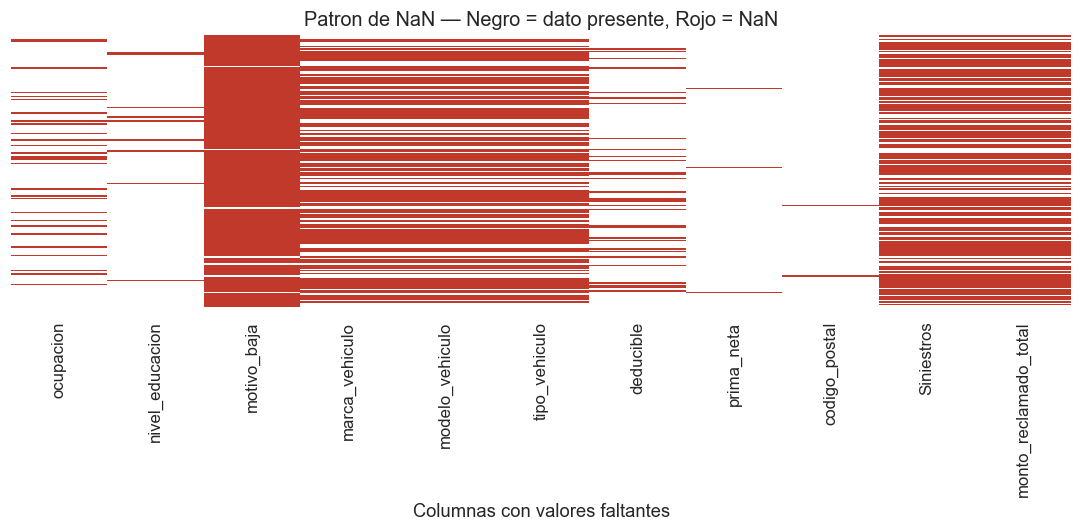

Correlacion entre columnas con NaN:
                       ocupacion  nivel_educacion  motivo_baja  \
ocupacion                  1.000            0.037        0.083   
nivel_educacion            0.037            1.000        0.041   
motivo_baja                0.083            0.041        1.000   
marca_vehiculo             0.083            0.054        0.036   
modelo_vehiculo            0.083            0.054        0.036   
tipo_vehiculo              0.083            0.054        0.036   
deducible                 -0.004           -0.095       -0.065   
prima_neta                -0.054           -0.027       -0.200   
codigo_postal             -0.044           -0.022       -0.254   
Siniestros                -0.022           -0.021        0.058   
monto_reclamado_total     -0.022           -0.021        0.058   

                       marca_vehiculo  modelo_vehiculo  tipo_vehiculo  \
ocupacion                       0.083            0.083          0.083   
nivel_educacion          

In [5]:
# ── Visualizar patron de NaN ──────────────────────────────────────────────────
# Mapa de calor de NaN — ver si hay patrones entre columnas
cols_con_nan = [c for c in df_raw.columns if df_raw[c].isna().any()]
muestra = df_raw[cols_con_nan].sample(200, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    muestra.isna(),
    cbar=False,
    yticklabels=False,
    cmap=['white','#C0392B'],
    ax=ax
)
ax.set_title('Patron de NaN — Negro = dato presente, Rojo = NaN', fontsize=13)
ax.set_xlabel('Columnas con valores faltantes')
plt.tight_layout()
plt.show()

# Buscar si los NaN co-ocurren — si cuando falta A tambien falta B,
# probablemente son del mismo tipo o la misma fuente
print('Correlacion entre columnas con NaN:')
print(muestra.isna().corr().round(3))

---
## Bloque 2 — SimpleImputer: Imputacion Univariada

El imputer mas simple y el mas usado en produccion.
Calcula un estadistico de la columna y lo aplica a todos los NaN.

In [6]:
# ── Preparar subset numerico para imputar ────────────────────────────────────
# Trabajamos con prima_neta — tiene ~2% NaN (MCAR: error de captura)
features_num = ['prima_neta','suma_asegurada','edad','deducible']

# Solo GMM para el ejemplo (deducible tiene NaN en Vida por diseno)
df_gmm = df_raw[df_raw['ramo']=='GMM'][features_num].copy()
print(f'GMM: {df_gmm.shape}')
print('NaN:')
print(df_gmm.isna().sum())
print()

# Guardar los valores originales (los que NO son NaN) para comparar despues
prima_original = df_gmm['prima_neta'].dropna().copy()
print(f'Primas originales disponibles: {len(prima_original):,}')

GMM: (22531, 4)
NaN:
prima_neta        461
suma_asegurada      0
edad                0
deducible           0
dtype: int64

Primas originales disponibles: 22,070


In [7]:
# ── Las 4 estrategias de SimpleImputer ───────────────────────────────────────
estrategias = {
    'Media':    SimpleImputer(strategy='mean'),
    'Mediana':  SimpleImputer(strategy='median'),
    'Moda':     SimpleImputer(strategy='most_frequent'),
    'Constante':SimpleImputer(strategy='constant', fill_value=0),
}

resultados_imp = {}
for nombre, imp in estrategias.items():
    df_imp = pd.DataFrame(
        imp.fit_transform(df_gmm),
        columns=features_num
    )
    resultados_imp[nombre] = df_imp['prima_neta'].copy()
    val = imp.statistics_[features_num.index('prima_neta')]
    print(f'{nombre:<12}: imputa con ${val:,.2f}')

Media       : imputa con $26,900.09
Mediana     : imputa con $17,864.00
Moda        : imputa con $11,000.00
Constante   : imputa con $0.00


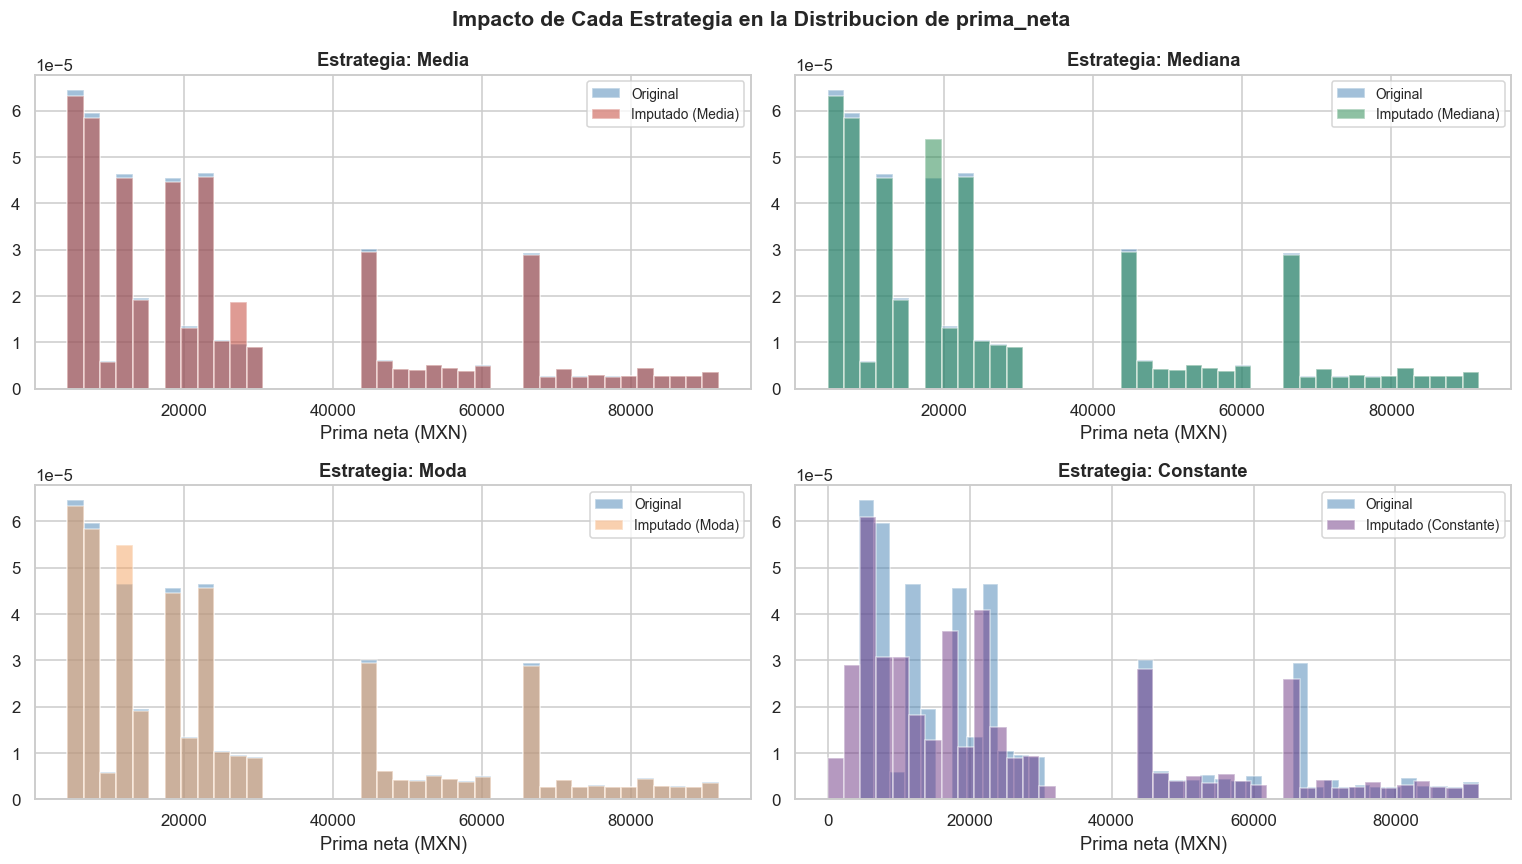

In [8]:
# ── Comparar las 4 estrategias visualmente ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colores = {'Media':'#C0392B','Mediana':'#1E8449','Moda':'#F4A261','Constante':'#6C3483'}

for ax, (nombre, serie) in zip(axes.flatten(), resultados_imp.items()):
    # Distribucion original (sin NaN)
    ax.hist(prima_original, bins=40, alpha=0.5,
            label='Original', color='steelblue', density=True)
    # Distribucion imputada
    ax.hist(serie, bins=40, alpha=0.5,
            label=f'Imputado ({nombre})', color=colores[nombre], density=True)
    ax.set_title(f'Estrategia: {nombre}', fontweight='bold')
    ax.set_xlabel('Prima neta (MXN)')
    ax.legend(fontsize=9)

fig.suptitle('Impacto de Cada Estrategia en la Distribucion de prima_neta',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# La estrategia CONSTANTE=0 es la que mas distorsiona — introduce un pico en 0
# Media y Mediana son similares aqui, pero con outliers la Mediana es mas robusta

### 📝 Ejercicio 1 — Comparar Estrategias (12 min)

**1a.** Para cada estrategia calcula: media, mediana y std de `prima_neta` despues de imputar.
Compara con los valores originales (sin NaN).

**1b.** Aplica el KS test (`stats.ks_2samp`) entre cada estrategia imputada y la distribucion original.
¿Cual tiene el p-value mas alto? (mayor p = mas similar a la original = mejor imputacion)

**1c.** ¿Que concluyes? ¿Cual estrategia recomendarias para `prima_neta` en esta cartera?

In [9]:
# Tu codigo aqui:



---
## Bloque 3 — KNNImputer e IterativeImputer

Cuando el NaN es **MAR** (depende de otras variables),
los metodos univariados son insuficientes.
KNN y MICE usan el contexto de cada registro para estimar el valor faltante.

In [10]:
# ── Crear un dataset con NaN MAR para demostrar la diferencia ────────────────
# Simulamos que en polizas de mayor suma_asegurada hay mas NaN en prima_neta
# (patron MAR: el NaN depende de suma_asegurada)
np.random.seed(42)
df_demo = df_gmm.copy()

# Introducir NaN con patron MAR: mas NaN en sumas altas
prob_nan = (df_demo['suma_asegurada'] / df_demo['suma_asegurada'].max()) * 0.3
mask_nan = np.random.binomial(1, prob_nan.fillna(0)) == 1
df_demo.loc[mask_nan, 'prima_neta'] = np.nan

print(f'NaN introducidos con patron MAR: {mask_nan.sum()} ({mask_nan.mean():.1%})')
print('Verificar patron MAR:')
q33, q66 = df_demo['suma_asegurada'].quantile([0.33, 0.66])
for label, cond in [('Suma baja',df_demo['suma_asegurada']<=q33),
                    ('Suma media',(df_demo['suma_asegurada']>q33)&(df_demo['suma_asegurada']<=q66)),
                    ('Suma alta',df_demo['suma_asegurada']>q66)]:
    tasa = df_demo.loc[cond,'prima_neta'].isna().mean()
    print(f'  {label}: {tasa:.1%} NaN')
print('Si la tasa sube con la suma → es MAR')

NaN introducidos con patron MAR: 2487 (11.0%)
Verificar patron MAR:
  Suma baja: 5.2% NaN
  Suma media: 10.9% NaN
  Suma alta: 26.5% NaN
Si la tasa sube con la suma → es MAR


In [11]:
# ── KNNImputer — requiere normalizar primero ──────────────────────────────────
X_demo = df_demo[features_num].copy()

# Paso 1: normalizar (KNN es sensible a escala)
scaler = StandardScaler()
# Fit solo en filas sin NaN para no contaminar
X_sin_nan = X_demo.dropna()
scaler.fit(X_sin_nan)

# Transformar todo (con NaN — sklearn lo permite)
X_scaled = scaler.transform(X_demo)

# Paso 2: imputar en escala normalizada
imp_knn = KNNImputer(n_neighbors=5)
t0 = time.time()
X_knn = imp_knn.fit_transform(X_scaled)
t_knn = time.time()-t0

# Paso 3: regresar a escala original
X_knn_orig = scaler.inverse_transform(X_knn)
df_knn = pd.DataFrame(X_knn_orig, columns=features_num)

print(f'KNNImputer — tiempo: {t_knn:.2f}s')
print(f'NaN restantes: {df_knn.isna().sum().sum()}')

KNNImputer — tiempo: 2.50s
NaN restantes: 0


In [12]:
# ── IterativeImputer (MICE) ───────────────────────────────────────────────────
imp_mice = IterativeImputer(
    max_iter=10,
    random_state=42,
    initial_strategy='median'
)
t0 = time.time()
X_mice = imp_mice.fit_transform(X_demo)
t_mice = time.time()-t0

df_mice = pd.DataFrame(X_mice, columns=features_num)
print(f'IterativeImputer — tiempo: {t_mice:.2f}s')
print(f'NaN restantes: {df_mice.isna().sum().sum()}')
print()

# ── Comparar los tres metodos donde habia NaN artificial ─────────────────────
# IMPORTANTE: df_knn y df_mice tienen indice 0,1,2... (creados desde numpy array)
# df_demo y df_gmm tienen el indice original del parquet
# Usamos .reset_index(drop=True) para alinear todos

# Mascara booleana con indice reseteado
idx_nan = df_demo['prima_neta'].isna().reset_index(drop=True)

# Valores verdaderos (los que existian antes de poner NaN), indice reseteado
prima_verdadera = df_gmm.loc[df_demo.index, 'prima_neta'].reset_index(drop=True)

# SimpleImputer — tambien resetear indice
prima_simple = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X_demo),
    columns=features_num
)['prima_neta']  # ya tiene indice 0,1,2...

# Ahora todos tienen el mismo indice — la comparacion funciona
print('Comparacion donde habia NaN (MAR):')
print(f'  Valor real promedio:     ${prima_verdadera[idx_nan].mean():,.2f}')
print(f'  SimpleImputer (mediana): ${prima_simple[idx_nan].mean():,.2f}')
print(f'  KNNImputer:              ${df_knn["prima_neta"][idx_nan].mean():,.2f}')
print(f'  IterativeImputer:        ${df_mice["prima_neta"][idx_nan].mean():,.2f}')
print()
print('Nota: con NaN MAR, KNN e IterativeImputer deberan acercarse mas')
print('al valor real que SimpleImputer porque usan el contexto de cada fila.')


IterativeImputer — tiempo: 0.06s
NaN restantes: 0

Comparacion donde habia NaN (MAR):
  Valor real promedio:     $46,573.24
  SimpleImputer (mediana): $17,600.00
  KNNImputer:              $43,564.51
  IterativeImputer:        $43,493.87

Nota: con NaN MAR, KNN e IterativeImputer deberan acercarse mas
al valor real que SimpleImputer porque usan el contexto de cada fila.


### 📝 Ejercicio 2 — KNN vs MICE (15 min)

**2a.** Para los registros donde introdujimos NaN artificialmente (variable `idx_nan`),
calcula el **Error Absoluto Medio (MAE)** entre el valor real y el valor imputado
por cada metodo: SimpleImputer, KNNImputer e IterativeImputer.

**2b.** Visualiza los tres metodos en un scatter:
eje X = valor real, eje Y = valor imputado.
El metodo perfecto tendria todos los puntos en la diagonal y=x.

**2c.** Prueba KNNImputer con k=3, k=5, k=10 y k=20.
¿Cual k da el menor MAE para este dataset?

**2d.** ¿En que situaciones de la cartera real usarias MICE en lugar de SimpleImputer?

In [13]:
# Tu codigo aqui:



---
## Bloque 4 — Evaluar el Impacto


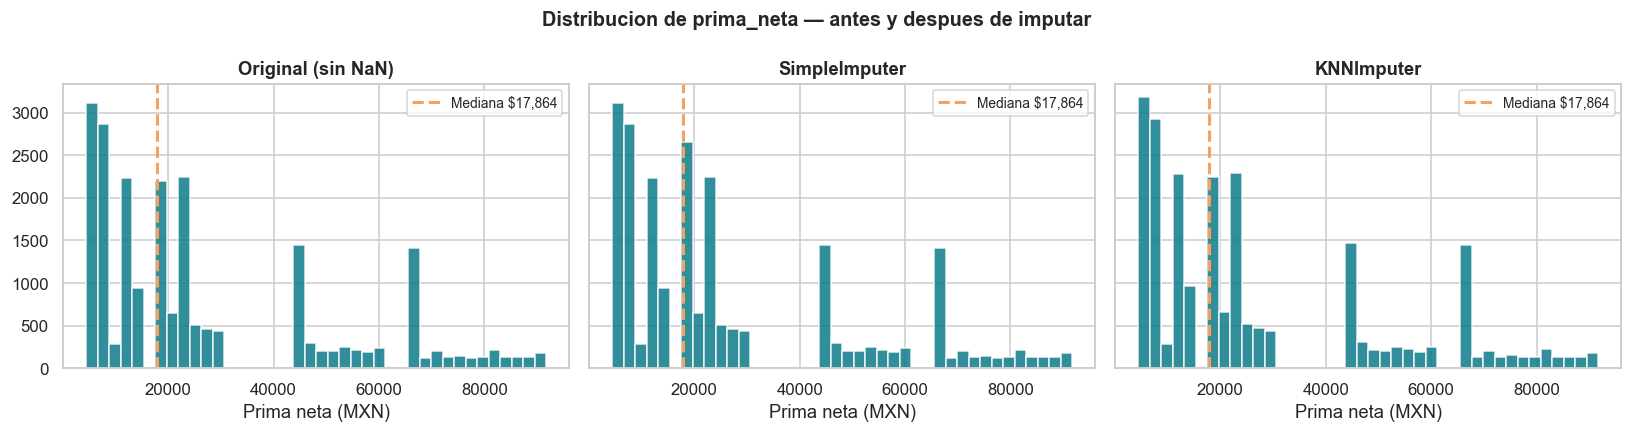

In [14]:
# ── Comparar distribuciones antes y despues ──────────────────────────────────
# Dataset completo — comparar SimpleImputer vs KNNImputer

df_trabajo = df_raw[df_raw['ramo']=='GMM'][features_num].copy()
prima_original_full = df_trabajo['prima_neta'].dropna()

# SimpleImputer con mediana
df_simple = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(df_trabajo),
    columns=features_num
)

# KNNImputer
scaler2 = StandardScaler()
X_sc2 = scaler2.fit_transform(df_trabajo)
X_knn2 = KNNImputer(n_neighbors=5).fit_transform(X_sc2)
df_knn2 = pd.DataFrame(scaler2.inverse_transform(X_knn2), columns=features_num)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (nombre, serie) in zip(axes, [
    ('Original (sin NaN)', prima_original_full),
    ('SimpleImputer',      df_simple['prima_neta']),
    ('KNNImputer',         df_knn2['prima_neta']),
]):
    ax.hist(serie, bins=40, color='#0D7A8A', edgecolor='white', alpha=0.85)
    ax.axvline(serie.median(), color='#F4A261', linewidth=2,
               linestyle='--', label=f'Mediana ${serie.median():,.0f}')
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Prima neta (MXN)')
    ax.legend(fontsize=9)

fig.suptitle('Distribucion de prima_neta — antes y despues de imputar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── KS Test formal ───────────────────────────────────────────────────────────
for nombre, serie in [('SimpleImputer', df_simple['prima_neta']),
                      ('KNNImputer',    df_knn2['prima_neta'])]:
    ks, pv = stats.ks_2samp(prima_original_full, serie)
    print(f'{nombre:<18}: KS={ks:.4f}  p={pv:.4f}  '","
          f"{'OK - no distorsiona' if pv>0.05 else 'DISTORSIONA la distribucion'}")
print()
print('p > 0.05 significa que la imputacion no distorsiona significativamente')

SimpleImputer     : KS=0.0100  p=0.2110  ,OK - no distorsiona
KNNImputer        : KS=0.0037  p=0.9980  ,OK - no distorsiona

p > 0.05 significa que la imputacion no distorsiona significativamente


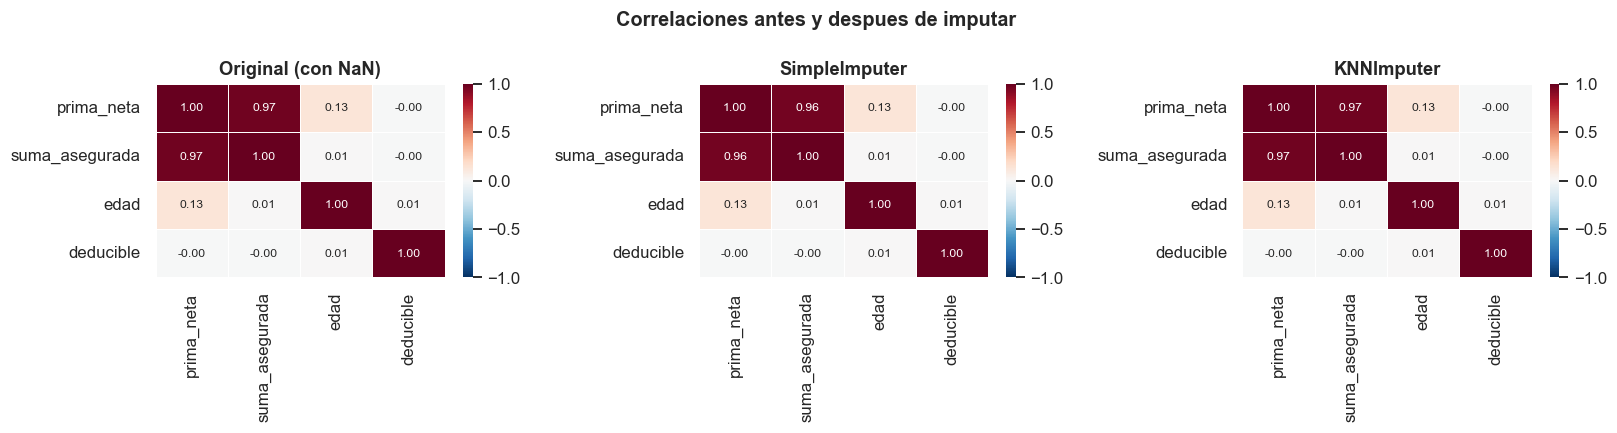

Diferencia maxima en correlaciones: 0.0111


In [16]:
# ── Comparar correlaciones antes y despues ───────────────────────────────────
corr_original = df_trabajo.corr(numeric_only=True)
corr_simple   = df_simple.corr(numeric_only=True)
corr_knn      = df_knn2.corr(numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kws = dict(annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
           linewidths=0.5, annot_kws={'size':8})

sns.heatmap(corr_original, ax=axes[0], **kws)
axes[0].set_title('Original (con NaN)', fontweight='bold')
sns.heatmap(corr_simple, ax=axes[1], **kws)
axes[1].set_title('SimpleImputer', fontweight='bold')
sns.heatmap(corr_knn, ax=axes[2], **kws)
axes[2].set_title('KNNImputer', fontweight='bold')

fig.suptitle('Correlaciones antes y despues de imputar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

diff = (corr_simple - corr_knn).abs()
print(f'Diferencia maxima en correlaciones: {diff.max().max():.4f}')

---
## Ejercicio Integrador — Pipeline Completo de Imputacion

Construye el pipeline de imputacion completo para preparar la cartera
para un modelo predictivo. Cada decision debe estar justificada.

### Las 4 Fases

**Fase 1 — Diagnostico**
Para cada columna con NaN, determina si es MCAR, MAR o MNAR.
Justifica con datos — no intuicion.

**Fase 2 — Estrategia por columna**
Diseña la estrategia de imputacion para cada columna.
No todas las columnas necesitan el mismo metodo.

**Fase 3 — Implementar y evaluar**
Aplica las estrategias. Para las columnas numericas clave,
verifica con KS test que la distribucion no se distorsiona.

**Fase 4 — Impacto en el modelo**
Entrena tres Pipelines sklearn (SimpleImputer, KNNImputer, IterativeImputer)
con LinearRegression para predecir `prima_total`.
Compara R2 y MAE. ¿Que metodo de imputacion da el mejor modelo?

In [17]:
# FASE 1 — Diagnostico
# Tu codigo aqui:



In [18]:
# FASE 2 — Estrategia por columna
# Tu codigo aqui:



In [19]:
# FASE 3 — Implementar y evaluar
# Tu codigo aqui:



In [20]:
# FASE 4 — Impacto en el modelo
# Estructura sugerida:
features_modelo = ['edad','suma_asegurada','deducible','n_siniestros']
df_modelo = df_raw[features_modelo + ['prima_total']].dropna(subset=['prima_total'])
X = df_modelo[features_modelo]
y = df_modelo['prima_total']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tu codigo: construye 3 pipelines y compara R2 y MAE


KeyError: "['n_siniestros'] not in index"

---
## Resumen

| Metodo | Cuando usarlo | Ventaja | Limitacion |
|--------|--------------|---------|------------|
| **SimpleImputer** | MCAR, pocas filas afectadas | Rapido, reproducible | Ignora relaciones entre variables |
| **KNNImputer** | MAR, variables correlacionadas | Usa contexto local | Lento, sensible a escala |
| **IterativeImputer** | MAR, muchas variables correlacionadas | Gold standard estadistico | Mas lento, requiere ajuste |

**Regla de oro:** fit() solo en datos de entrenamiento. Nunca en test.